# BERT Text Embedding — Amazon All Beauty Reviews
### Pipeline
1. Load pre-cleaned interactions from `cleaned_interactions.jsonl` (output of `preprocess.py`)
2. Apply text-specific cleaning (HTML, entities, title+body merge)
3. Embed each `(user, item)` review with `sentence-transformers/all-mpnet-base-v2`
4. Save one record per interaction to `interactions_text_embeddings.jsonl`


In [1]:
!pip install sentence-transformers scikit-learn matplotlib pandas tqdm

In [2]:
import json
import re
import html
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from collections import defaultdict, Counter
from tqdm import tqdm

import torch
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

random.seed(42)
print("Imports OK")

Imports OK


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
CLEAN_PATH   = "cleaned_interactions.jsonl"   # output of preprocess.py
OUTPUT_PATH  = "interactions_text_embeddings.jsonl"
MODEL_NAME   = "sentence-transformers/all-mpnet-base-v2"
MAX_USERS    = 500
MIN_REVIEWS  = 3                               # must match preprocess.py
random.seed(42)
print(f"Config loaded. Reading from: {CLEAN_PATH}")

Config loaded. Reading from: cleaned_interactions.jsonl


In [4]:
# ── Text-specific cleaning helpers ────────────────────────────────────────────
# Note: core field validation, deduplication, and user-level filtering are
# already handled by preprocess.py. These functions handle text-only concerns.

def clean_review_text(text: str, title: str = "") -> str:
    """
    Merge review title + body, strip HTML tags and entities, normalise whitespace.
    Title carries useful one-line sentiment signal so we prepend it.
    Returns empty string if nothing usable remains.
    """
    if not isinstance(text, str):
        text = ""
    if not isinstance(title, str):
        title = ""

    # Combine: "<title> . <body>"
    combined = (title.strip() + " . " + text.strip()).strip(" .")

    # Decode HTML entities  (&amp; → &,  &quot; → ",  &#39; → ', etc.)
    combined = html.unescape(combined)

    # Remove any remaining HTML tags
    combined = re.sub(r"<[^>]+>", " ", combined)

    # Collapse all whitespace (newlines, tabs, multiple spaces)
    combined = re.sub(r"\s+", " ", combined).strip()

    return combined


def has_usable_text(text: str, title: str = "") -> bool:
    """Return True if the cleaned combined text is non-empty."""
    return len(clean_review_text(text, title)) > 0


print("Text cleaning helpers defined.")
print("  clean_review_text(text, title) → str")
print("  has_usable_text(text, title)   → bool")

Text cleaning helpers defined.
  clean_review_text(text, title) → str
  has_usable_text(text, title)   → bool


In [5]:
# ── Load pre-cleaned interactions from preprocess.py output ───────────────────
raw_records = []
with open(CLEAN_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            raw_records.append(json.loads(line))

print(f"Clean interactions loaded : {len(raw_records)}")

# ── Keep only records that have usable text (image-only records are skipped) ───
text_records = [
    r for r in raw_records
    if has_usable_text(r.get("text", ""), r.get("title", ""))
]
print(f"Records with usable text  : {len(text_records)}")

# ── Group by user, enforce MIN_REVIEWS, sample up to MAX_USERS ────────────────
user_map = defaultdict(list)
for r in text_records:
    user_map[r["user_id"]].append(r)

qualified_uids = sorted(
    uid for uid, recs in user_map.items() if len(recs) >= MIN_REVIEWS
)
print(f"Qualified users (≥{MIN_REVIEWS} text reviews): {len(qualified_uids)}")

sampled_uids = random.sample(qualified_uids, min(MAX_USERS, len(qualified_uids)))
print(f"Users sampled for embedding : {len(sampled_uids)}")

# Build filtered_data dict for EDA and embedding cells below
filtered_data = {}
for uid in sampled_uids:
    recs = user_map[uid]
    reviews = []
    for r in recs:
        reviews.append({
            "asin"       : r.get("asin"),
            "parent_asin": r.get("parent_asin"),
            "text"       : clean_review_text(r.get("text", ""), r.get("title", "")),
            "rating"     : r.get("rating"),
            "timestamp"  : r.get("timestamp"),
            "verified"   : r.get("verified_purchase") or r.get("verified"),
            "images"     : r.get("images", []),
        })
    filtered_data[uid] = {
        "user_id"    : uid,
        "num_reviews": len(reviews),
        "reviews"    : reviews,
    }

total_reviews = sum(v["num_reviews"] for v in filtered_data.values())
print(f"Total interactions to embed : {total_reviews}")

# Peek at one user
sample_uid  = sampled_uids[0]
sample_user = filtered_data[sample_uid]
print(f"\nSample user : {sample_uid}  ({sample_user['num_reviews']} reviews)")
for i, rev in enumerate(sample_user["reviews"][:3]):
    print(f"  [{i+1}] rating={rev['rating']} | text[:80]=\"{rev['text'][:80]}…\"")

Clean interactions loaded : 35624
Records with usable text  : 35624
Qualified users (≥3 text reviews): 8201
Users sampled for embedding : 1000
Total interactions to embed : 4144

Sample user : AEWQAI5XMEZ6KUHBRX5UENAUSJYA  (3 reviews)
  [1] rating=5.0 | text[:80]="Excellent . Just as described…"
  [2] rating=5.0 | text[:80]="Excellent product . Excellent product…"
  [3] rating=5.0 | text[:80]="Five Stars . Good product…"


In [6]:
# ── EDA: per-user summary + aggregate stats + rating distribution ─────────────
records_eda = []
for uid, user in filtered_data.items():
    ratings  = [r["rating"] for r in user["reviews"] if r["rating"] is not None]
    n_images = sum(len(r["images"]) for r in user["reviews"])
    n_text   = sum(1 for r in user["reviews"] if r.get("text"))
    verified = sum(1 for r in user["reviews"] if r.get("verified"))

    records_eda.append({
        "user_id"      : uid,
        "num_reviews"  : user["num_reviews"],
        "mean_rating"  : round(np.mean(ratings), 2) if ratings else None,
        "min_rating"   : min(ratings)                if ratings else None,
        "max_rating"   : max(ratings)                if ratings else None,
        "rating_std"   : round(np.std(ratings), 2)  if ratings else None,
        "n_with_images": n_images,
        "n_with_text"  : n_text,
        "n_verified"   : verified,
    })

df = pd.DataFrame(records_eda).sort_values("num_reviews", ascending=False)

print("=" * 80)
print(f"{'USER SUMMARY':^80}")
print("=" * 80)
print(df.to_string(index=False))

print("\n" + "=" * 80)
print(f"{'AGGREGATE STATS':^80}")
print("=" * 80)
agg = {
    "Total users"           : len(df),
    "Total reviews"         : int(df["num_reviews"].sum()),
    "Avg reviews / user"    : round(df["num_reviews"].mean(), 2),
    "Median reviews / user" : df["num_reviews"].median(),
    "Max reviews (one user)": int(df["num_reviews"].max()),
    "Min reviews (one user)": int(df["num_reviews"].min()),
    "Overall mean rating"   : round(df["mean_rating"].mean(), 2),
    "Overall rating std"    : round(df["mean_rating"].std(), 2),
    "Reviews with images"   : int(df["n_with_images"].sum()),
    "Reviews with text"     : int(df["n_with_text"].sum()),
    "Verified reviews"      : int(df["n_verified"].sum()),
}
col_w = max(len(k) for k in agg) + 2
for k, v in agg.items():
    print(f"  {k:<{col_w}}: {v}")

print("\n" + "=" * 80)
print(f"{'RATING DISTRIBUTION (all reviews)':^80}")
print("=" * 80)
all_ratings = [
    r["rating"]
    for user in filtered_data.values()
    for r in user["reviews"]
    if r["rating"] is not None
]
dist  = Counter(all_ratings)
total = len(all_ratings)
for star in sorted(dist):
    pct = dist[star] / total * 100
    bar = "█" * int(pct / 2)
    print(f"  {star}★  {bar:<25} {dist[star]:>4} ({pct:5.1f}%)")

                                  USER SUMMARY                                  
                       user_id  num_reviews  mean_rating  min_rating  max_rating  rating_std  n_with_images  n_with_text  n_verified
AEOK4TQIKGO23SJKZ6PW4FETNNDA_1           68         4.24         1.0         5.0        0.79             18           68           1
  AH3BXW7KLIS2VAE56UXJS2NS7I5A           58         3.95         2.0         5.0        0.84              0           58           0
  AE5ESL52LWWBJTSFOAXSFZA3XCGQ           47         3.98         1.0         5.0        1.14             13           47           0
  AECADZLPUNH3BDNACLFF7PSHN5MQ           40         4.82         4.0         5.0        0.38             42           40           0
  AGV5NQ4JDQD6NHXVF6AVZPVDX66Q           32         4.28         1.0         5.0        1.35             18           32           1
  AGXMWJK3YL4SV5FJ27JEJZPZHRBA           30         4.10         2.0         5.0        0.83             48           30 

In [7]:
# ── Load sentence-transformers model ──────────────────────────────────────────
# We use all-mpnet-base-v2 instead of a classification-fine-tuned BERT because:
#   • Classification fine-tuning collapses the CLS embedding space into a few
#     decision boundaries (positive / negative / neutral), destroying the
#     fine-grained sentiment geometry that prototype learning depends on.
#   • all-mpnet-base-v2 is trained with a metric-learning objective (cosine
#     similarity over sentence pairs), producing a smooth, graded embedding
#     space where semantically similar sentences are geometrically close —
#     exactly what the prototype attention mechanism needs.
#   • L2-normalised output means cosine similarity == dot product, which
#     matches the prototype similarity computation  vi^T sk  in the paper.

sbert = SentenceTransformer(MODEL_NAME)
sbert.eval()
EMB_DIM = sbert.get_sentence_embedding_dimension()
print(f"Model loaded : {MODEL_NAME}")
print(f"Embedding dim: {EMB_DIM}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded : sentence-transformers/all-mpnet-base-v2
Embedding dim: 768


/tmp/ipykernel_3140/703362742.py:15: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  EMB_DIM = sbert.get_sentence_embedding_dimension()


In [8]:
# ── Embedding functions ────────────────────────────────────────────────────────

def get_review_embedding(text: str) -> np.ndarray:
    """
    Embed a single cleaned review string.
    Returns L2-normalised vector of shape (EMB_DIM,).
    normalize_embeddings=True ensures cosine similarity == dot product,
    matching the prototype attention formula  vi^T sk.
    """
    if not text.strip():
        return np.zeros(EMB_DIM, dtype=np.float32)
    with torch.no_grad():
        emb = sbert.encode(
            text,
            convert_to_numpy=True,
            normalize_embeddings=True,   # L2-normalise
            show_progress_bar=False,
        )
    return emb.astype(np.float32)


print("Embedding function defined.")
print(f"  get_review_embedding(text) → np.ndarray shape ({EMB_DIM},)")

Embedding function defined.
  get_review_embedding(text) → np.ndarray shape (768,)


In [9]:
# ── Generate per-interaction embeddings ───────────────────────────────────────
# We embed at the (user, item) interaction level, NOT at the user level.
# The prototype module needs individual  tui  vectors per interaction,
# not a mean-pooled user vector, so that rating supervision can align
# each review's embedding to the correct sentiment prototype.

print("Embedding reviews…\n")

# interaction_embs: list of dicts, one per (user, asin) pair
interaction_embs = []

# user_embeddings / user_ids: kept for visualisation only (mean-pooled per user)
user_ids        = []
user_embeddings = []

for uid, user_obj in tqdm(filtered_data.items(), desc="Users"):
    review_vecs = []

    for rev in user_obj["reviews"]:
        text = rev.get("text", "")
        if not text:
            continue

        emb = get_review_embedding(text)

        # Store full interaction record — this is the output unit
        interaction_embs.append({
            "user_id"       : uid,
            "asin"          : rev["asin"],
            "parent_asin"   : rev.get("parent_asin"),
            "rating"        : rev["rating"],
            "timestamp"     : rev.get("timestamp"),
            "text_embedding": emb,           # np.ndarray (EMB_DIM,)
        })
        review_vecs.append(emb)

    # Mean-pool for visualisation
    if review_vecs:
        user_ids.append(uid)
        user_embeddings.append(np.mean(review_vecs, axis=0))

user_embeddings = np.array(user_embeddings)   # (n_users, EMB_DIM)

print(f"\nTotal interactions embedded : {len(interaction_embs)}")
print(f"Users with ≥1 embedding     : {len(user_ids)}")
print(f"User-embedding matrix shape : {user_embeddings.shape}")

# Spot-check
ex = interaction_embs[0]
print(f"\nSpot-check — first record:")
print(f"  user_id  : {ex['user_id']}")
print(f"  asin     : {ex['asin']}")
print(f"  rating   : {ex['rating']}")
print(f"  emb shape: {ex['text_embedding'].shape}")
print(f"  emb norm : {np.linalg.norm(ex['text_embedding']):.4f}  (should be ~1.0)")

Embedding reviews…



Users: 100%|██████████| 1000/1000 [00:57<00:00, 17.25it/s]


Total interactions embedded : 4144
Users with ≥1 embedding     : 1000
User-embedding matrix shape : (1000, 768)

Spot-check — first record:
  user_id  : AEWQAI5XMEZ6KUHBRX5UENAUSJYA
  asin     : B07MTZ77ZH
  rating   : 5.0
  emb shape: (768,)
  emb norm : 1.0000  (should be ~1.0)


In [10]:
# ── Save per-interaction text embeddings ──────────────────────────────────────
# Output schema (one JSON line per interaction):
# {
#   "user_id"       : str,
#   "asin"          : str,          ← JOIN KEY with image embeddings file
#   "parent_asin"   : str,
#   "rating"        : float,        ← supervision signal for prototype learning
#   "timestamp"     : int,
#   "text_embedding": list[float],  ← len = EMB_DIM (768)
# }

with open(OUTPUT_PATH, "w") as f:
    for record in interaction_embs:
        out = {
            "user_id"       : record["user_id"],
            "asin"          : record["asin"],
            "parent_asin"   : record["parent_asin"],
            "rating"        : record["rating"],
            "timestamp"     : record["timestamp"],
            "text_embedding": record["text_embedding"].tolist(),
        }
        f.write(json.dumps(out) + "\n")

print(f"Saved {len(interaction_embs)} interaction records → {OUTPUT_PATH}")
print(f"Each record contains a text_embedding of dim {EMB_DIM}.")
print("Next step: run interactions_image_embeddings.jsonl then merge.py")

Saved 4144 interaction records → interactions_text_embeddings.jsonl
Each record contains a text_embedding of dim 768.
Next step: run interactions_image_embeddings.jsonl then merge.py


In [11]:
# ── Visualisation: PCA + t-SNE on mean-pooled user embeddings ─────────────────
# (Uses mean-pooled user vectors for visualisation only — not used in training)

perplexity = min(15, len(user_ids) - 1)

pca_2d  = PCA(n_components=2).fit_transform(user_embeddings)
tsne_2d = TSNE(
    n_components=2, perplexity=perplexity,
    random_state=42, n_iter=1000
).fit_transform(user_embeddings)

print(f"PCA  output shape : {pca_2d.shape}")
print(f"t-SNE output shape: {tsne_2d.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


PCA  output shape : (1000, 2)
t-SNE output shape: (1000, 2)


In [12]:
# ── Cosine similarity between user embeddings ─────────────────────────────────
cos_sim   = cosine_similarity(user_embeddings)
n         = len(user_ids)
upper_idx = np.triu_indices(n, k=1)
sim_vals  = cos_sim[upper_idx]

high_thr = np.percentile(sim_vals, 90)
low_thr  = np.percentile(sim_vals, 10)

similar_pairs    = [(upper_idx[0][k], upper_idx[1][k])
                    for k in range(len(sim_vals)) if sim_vals[k] >= high_thr]
dissimilar_pairs = [(upper_idx[0][k], upper_idx[1][k])
                    for k in range(len(sim_vals)) if sim_vals[k] <= low_thr]

print(f"Cosine sim — min: {sim_vals.min():.3f} | mean: {sim_vals.mean():.3f} | max: {sim_vals.max():.3f}")
print(f"High-sim threshold (≥p90): {high_thr:.3f}  → {len(similar_pairs)} pairs")
print(f"Low-sim  threshold (≤p10): {low_thr:.3f}  → {len(dissimilar_pairs)} pairs")

Cosine sim — min: -0.147 | mean: 0.413 | max: 0.933
High-sim threshold (≥p90): 0.594  → 49950 pairs
Low-sim  threshold (≤p10): 0.225  → 49950 pairs


/tmp/ipykernel_3140/1636555497.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


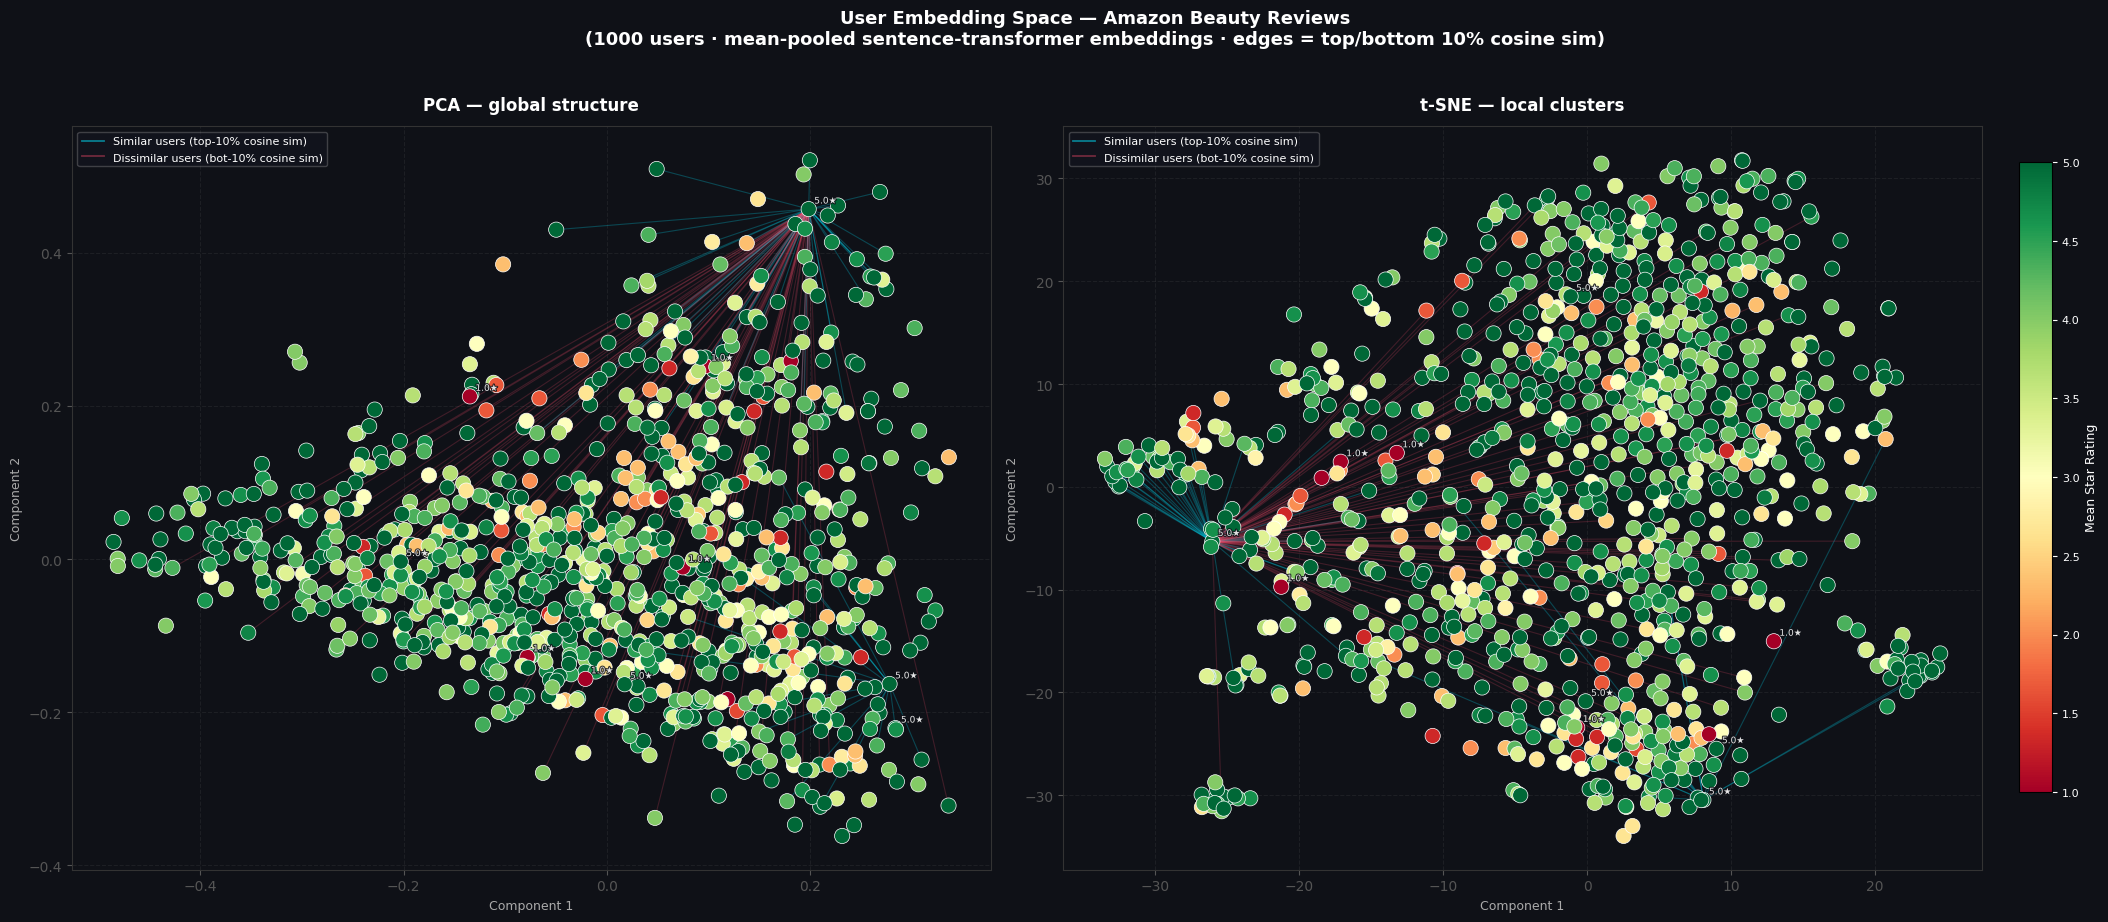

Saved → user_embeddings_visualization.png


In [13]:
# ── Plot: PCA + t-SNE coloured by mean rating ─────────────────────────────────
mean_ratings = np.array([
    np.mean([float(r.get("rating", 3)) for r in filtered_data[uid]["reviews"]])
    for uid in user_ids
])

def draw_edges(ax, coords, pairs, color, alpha, lw, label, max_edges=60):
    drawn = 0
    for i, j in pairs:
        if drawn >= max_edges:
            break
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            color=color, alpha=alpha, linewidth=lw, zorder=1,
        )
        drawn += 1
    ax.plot([], [], color=color, alpha=min(alpha * 2, 1.0),
            linewidth=lw + 0.5, label=label)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.patch.set_facecolor("#0f1117")
for ax in axes:
    ax.set_facecolor("#0f1117")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

cmap = plt.cm.RdYlGn

for ax, coords, title in [
    (axes[0], pca_2d,  "PCA — global structure"),
    (axes[1], tsne_2d, "t-SNE — local clusters"),
]:
    draw_edges(ax, coords, similar_pairs,    "#00e5ff", 0.25, 0.8,
               "Similar users (top-10% cosine sim)")
    draw_edges(ax, coords, dissimilar_pairs, "#ff4d6d", 0.20, 0.8,
               "Dissimilar users (bot-10% cosine sim)")

    sc = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=mean_ratings, cmap=cmap, vmin=1, vmax=5,
        s=120, edgecolors="#ffffff", linewidths=0.5, zorder=4,
    )

    top5    = np.argsort(mean_ratings)[-5:]
    bottom5 = np.argsort(mean_ratings)[:5]
    for idx in np.concatenate([top5, bottom5]):
        ax.annotate(
            f"{mean_ratings[idx]:.1f}★",
            xy=(coords[idx, 0], coords[idx, 1]),
            xytext=(4, 4), textcoords="offset points",
            fontsize=6.5, color="white", alpha=0.85,
            path_effects=[pe.withStroke(linewidth=1.5, foreground="#0f1117")],
            zorder=5,
        )

    ax.set_title(title, fontsize=12, fontweight="bold", color="white", pad=12)
    ax.set_xlabel("Component 1", fontsize=9, color="#aaa")
    ax.set_ylabel("Component 2", fontsize=9, color="#aaa")
    ax.tick_params(colors="#555")
    ax.grid(True, linestyle="--", alpha=0.12, color="#888")

    legend = ax.legend(fontsize=8, framealpha=0.25, loc="upper left",
                       labelcolor="white", facecolor="#1a1a2e")
    for text in legend.get_texts():
        text.set_color("white")

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
cb = fig.colorbar(sc, cax=cbar_ax, cmap=cmap)
cb.set_label("Mean Star Rating", color="white", fontsize=9)
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white", fontsize=8)

fig.suptitle(
    f"User Embedding Space — Amazon Beauty Reviews\n"
    f"({len(user_ids)} users · mean-pooled sentence-transformer embeddings · "    f"edges = top/bottom 10% cosine sim)",
    fontsize=13, fontweight="bold", color="white", y=1.02,
)
plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig("user_embeddings_visualization.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → user_embeddings_visualization.png")